In [1]:
# create a dataset
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 300
#Features
hours_study = np.random.uniform(0, 8, n_samples)
sleep_hours = np.random.uniform(4, 9, n_samples)
distractions = np.random.randint(0, 11, n_samples)
attendance = np.random.uniform(50, 100, n_samples)
prev_grade = np.random.uniform(0, 20, n_samples)

noise = np.random.normal(0, 5, n_samples)
score = (
    6 * hours_study +
    0.4 * attendance +
    1.0 * prev_grade -
    2 * distractions +
    noise
)
score = np.clip(score, 0, 100)

passed = (score >= 60).astype(int)

df = pd.DataFrame({
    "hours_study": hours_study,
    "sleep_hours": sleep_hours,
    "distractions": distractions,
    "attendance": attendance,
    "prev_grade": prev_grade,
    "score": score,
    "passed": passed
})
df.to_csv("students_data.csv", index=False)
df.head()


,hours_study,sleep_hours,distractions,attendance,prev_grade,score,passed
0,2.996321,4.258409,4,96.042094,10.739488,59.376177,0
1,7.605714,6.656773,1,93.494818,11.858799,89.453295,1
2,5.855952,6.703176,9,75.941903,11.601724,58.459615,0
3,4.789268,7.187150,5,79.563772,1.829737,47.216078,0
4,1.248149,7.630457,4,69.950135,17.549217,44.068194,0


In [3]:
# 1 - load csv
df = pd.read_csv("students_data.csv")
print("Dataframe format:", df.shape)
df.head()

Dataframe format: (300, 7)


,hours_study,sleep_hours,distractions,attendance,prev_grade,score,passed
0,2.996321,4.258409,4,96.042094,10.739488,59.376177,0
1,7.605714,6.656773,1,93.494818,11.858799,89.453295,1
2,5.855952,6.703176,9,75.941903,11.601724,58.459615,0
3,4.789268,7.187150,5,79.563772,1.829737,47.216078,0
4,1.248149,7.630457,4,69.950135,17.549217,44.068194,0


In [4]:
# 2 - Separating X and y
X = df.drop(["passed", "score"], axis=1).values
y = df["passed"].values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 5)
y shape: (300,)


In [5]:
# 3 - Split into Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (240, 5) (240,)
Test : (60, 5) (60,)


In [6]:
# 4 - Normalization (StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Example from X_train_scaled[0]:")
print(X_train_scaled[0])

Example from X_train_scaled[0]:
[ 1.4036793  -1.45514085  0.02801547 -0.88194797 -1.45707093]


In [8]:
# 5 - Definition of 10 sklearn models
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)"          : KNeighborsClassifier(n_neighbors=5),
    "SVC (RBF)"          : SVC(kernel="rbf"),
    "Linear SVC"         : LinearSVC(),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingClassifier(random_state=42),
    "Gaussian NB"        : GaussianNB(),
    "Perceptron"         : Perceptron(random_state=42),
    "SGD Classifier"     : SGDClassifier(random_state=42)
}

In [16]:
#Accuracy

from sklearn.metrics import accuracy_score

results = []
y_preds = {}
for name, model in models.items():
    # Train (fit) the model
    model.fit(X_train_scaled, y_train)
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    # Store predictions for later use (precision/recall/confusion matrix)
    y_preds[name] = y_pred
    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)
    # Add to results list
    results.append((name, acc))
# Convert to DataFrame for nice display
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("✅ Model accuracies:")
results_df

✅ Model accuracies:


,Model,Accuracy
3,Linear SVC,0.966667
0,Logistic Regression,0.950000
9,SGD Classifier,0.950000
2,SVC (RBF),0.950000
8,Perceptron,0.916667
5,Random Forest,0.916667
6,Gradient Boosting,0.916667
7,Gaussian NB,0.900000
1,KNN (k=5),0.883333
4,Decision Tree,0.783333


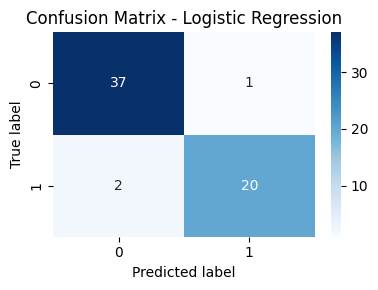

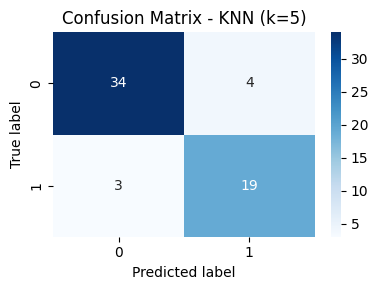

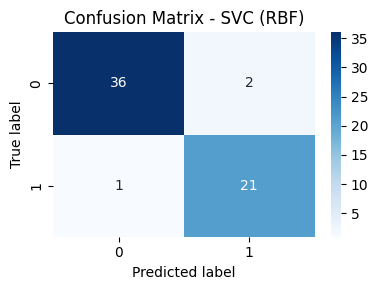

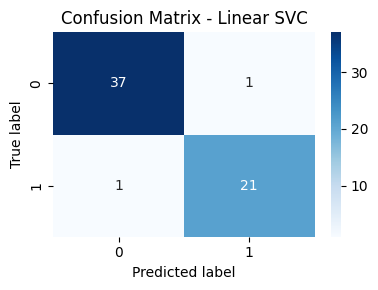

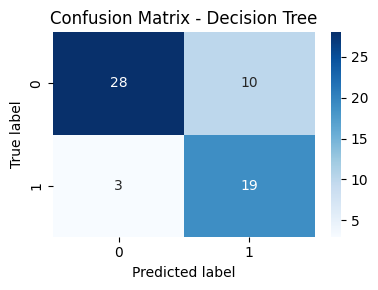

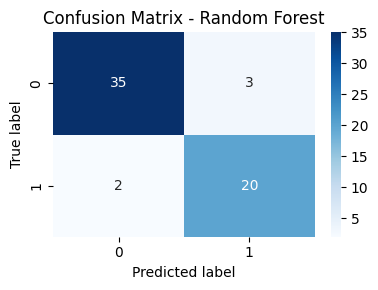

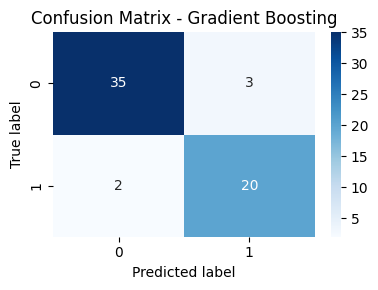

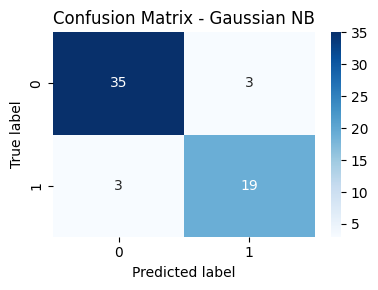

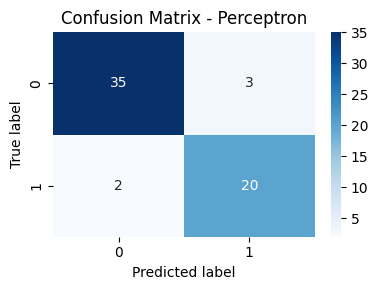

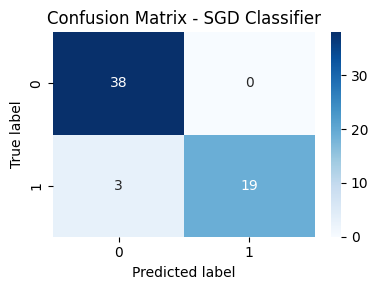

In [18]:
# 8 - Confusion matrix for each model

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, y_pred in y_preds.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [17]:
#Precision / Recall / F1-score
from sklearn.metrics import precision_score, recall_score, f1_score
metrics_list = []

for name, y_pred in y_preds.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary")
    rec  = recall_score(y_test, y_pred, average="binary")
    f1   = f1_score(y_test, y_pred, average="binary")
    metrics_list.append((name, acc, prec, rec, f1))

metrics_df = pd.DataFrame(
    metrics_list,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

metrics_df = metrics_df.sort_values(by="F1-score", ascending=False)

print("✅ Evaluation metrics (sorted by F1-score):")
metrics_df

✅ Evaluation metrics (sorted by F1-score):


,Model,Accuracy,Precision,Recall,F1-score
3,Linear SVC,0.966667,0.954545,0.954545,0.954545
2,SVC (RBF),0.950000,0.913043,0.954545,0.933333
0,Logistic Regression,0.950000,0.952381,0.909091,0.930233
9,SGD Classifier,0.950000,1.000000,0.863636,0.926829
8,Perceptron,0.916667,0.869565,0.909091,0.888889
5,Random Forest,0.916667,0.869565,0.909091,0.888889
6,Gradient Boosting,0.916667,0.869565,0.909091,0.888889
7,Gaussian NB,0.900000,0.863636,0.863636,0.863636
1,KNN (k=5),0.883333,0.826087,0.863636,0.844444
4,Decision Tree,0.783333,0.655172,0.863636,0.745098


In [14]:
import pandas as pd

pd.DataFrame(reports["Random Forest"]).transpose()

,precision,recall,f1-score,support
0,0.945946,0.921053,0.933333,38.000000
1,0.869565,0.909091,0.888889,22.000000
accuracy,0.916667,0.916667,0.916667,0.916667
macro avg,0.907756,0.915072,0.911111,60.000000
weighted avg,0.917940,0.916667,0.917037,60.000000


In [19]:
best_model_name = metrics_df.iloc[0]["Model"]
print("Best model based on F1-score:", best_model_name)
best_model = models[best_model_name]
best_y_pred = y_preds[best_model_name]


Best model based on F1-score: Linear SVC


In [21]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_embedded = tsne.fit_transform(X_test_scaled)
print("t-SNE shape:", X_test_embedded.shape)

t-SNE shape: (60, 2)


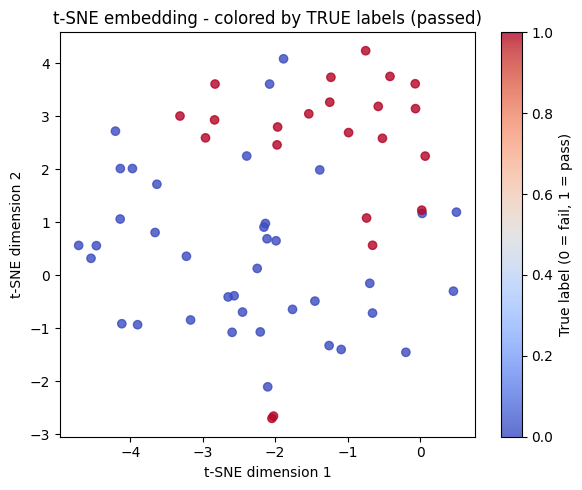

In [22]:
# Plot t-SNE colored by TRUE labels
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_test_embedded[:, 0],
    X_test_embedded[:, 1],
    c=y_test,
    cmap="coolwarm",
    alpha=0.8
)
plt.title("t-SNE embedding - colored by TRUE labels (passed)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.colorbar(scatter, label="True label (0 = fail, 1 = pass)")
plt.tight_layout()
plt.show()

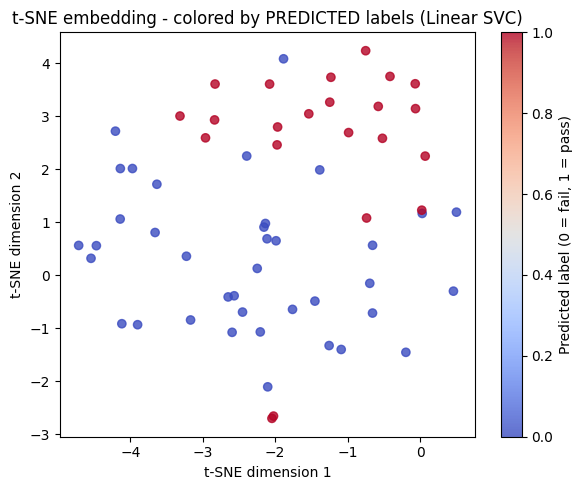

In [23]:
# Plot t-SNE colored by PREDICTED labels (best model)
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_test_embedded[:, 0],
    X_test_embedded[:, 1],
    c=best_y_pred,
    cmap="coolwarm",
    alpha=0.8
)
plt.title(f"t-SNE embedding - colored by PREDICTED labels ({best_model_name})")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.colorbar(scatter, label="Predicted label (0 = fail, 1 = pass)")
plt.tight_layout()
plt.show()


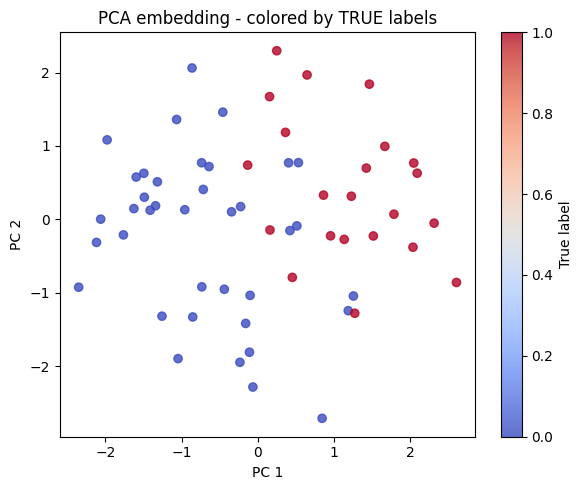

In [24]:
# 11 - Compare PCA vs t-SNE as embedding methods
from sklearn.decomposition import PCA
# PCA to 2D
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)
# Plot PCA
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap="coolwarm",
    alpha=0.8
)
plt.title("PCA embedding - colored by TRUE labels")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(scatter, label="True label")
plt.tight_layout()
plt.show()
